In [1]:
import torch

from PIL import Image
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection
)

In [2]:
MODEL_NAME = "facebook/detr-resnet-50"

print("Model:", MODEL_NAME)

Model: facebook/detr-resnet-50


In [3]:
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

print("Image processor loaded successfully")

Image processor loaded successfully


In [4]:
model = AutoModelForObjectDetection.from_pretrained(
    MODEL_NAME
)

print("Model loaded successfully")

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully


In [5]:
print(model)

DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvEncoder(
      (model): FeatureListNet(
        (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (bn1): DetrFrozenBatchNorm2d()
        (act1): ReLU(inplace=True)
        (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (layer1): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): DetrFrozenBatchNorm2d()
            (act1): ReLU(inplace=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): DetrFrozenBatchNorm2d()
            (drop_block): Identity()
            (act2): ReLU(inplace=True)
            (aa): Identity()
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): DetrFrozenBatchNorm2d()
            (act3): ReLU(inplace

In [7]:
print("Architecture:", model.config.model_type)
print("Number of labels:", model.config.num_labels)

print("\nFirst few labels:")

for label_id, label_name in list(model.config.id2label.items())[:10]:
    print(label_id, "->", label_name)

Architecture: detr
Number of labels: 91

First few labels:
0 -> N/A
1 -> person
10 -> traffic light
11 -> fire hydrant
12 -> street sign
13 -> stop sign
14 -> parking meter
15 -> bench
16 -> bird
17 -> cat


In [8]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


In [9]:
model = model.to(device)

print("Model moved to:", device)

Model moved to: cpu


In [10]:
image = Image.open("../images/road.jpg").convert("RGB")

print("Image size:", image.size)
print("Image mode:", image.mode)

Image size: (500, 334)
Image mode: RGB


In [11]:
inputs = processor(
    images=image,
    return_tensors="pt"
)

In [12]:
print(inputs)

{'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[ 1.4612,  1.4440,  1.4098,  ...,  0.5364,  0.4166,  0.3823],
          [ 1.5125,  1.4612,  1.3755,  ...,  0.5707,  0.3994,  0.3481],
          [ 1.6495,  1.5468,  1.2385,  ...,  0.6734,  0.3309,  0.2282],
          ...,
          [-0.4226, -0.4226, -0.4226,  ..., -0.2342, -0.2342, -0.2342],
          [-0.4226, -0.4226, -0.4226,  ..., -0.2513, -0.2513, -0.2513],
          [-0.4226, -0.4226, -0.4226,  ..., -0.2513, -0.2513, -0.2513]],

         [[ 0.8529,  0.8354,  0.8004,  ..., -0.2850, -0.4076, -0.4426],
          [ 0.9055,  0.8529,  0.7654,  ..., -0.2500, -0.4426, -0.4776],
          [ 1.0455,  0.9405,  0.6254,  ..., -0.1625, -0.5301, -0.6176],
          ...,
          [-0.4076, -0.4076, -0.4076,  ..., -0.4426, -0.4426, 

In [13]:
pixel_values = inputs["pixel_values"]

print("Type:", type(pixel_values))
print("Shape:", pixel_values.shape)
print("Data type:", pixel_values.dtype)

Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 3, 800, 1197])
Data type: torch.float32


In [14]:
inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

print("Inputs moved to:", device)

Inputs moved to: cpu


In [15]:
with torch.inference_mode():
    outputs = model(**inputs)

In [16]:
print(type(outputs))
print(outputs)

<class 'transformers.models.detr.modeling_detr.DetrObjectDetectionOutput'>
DetrObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[-13.5236,   5.8233,   1.5541,  ...,  -7.7779,  -5.1390,   6.2488],
         [-13.9639,   7.0151,   0.9776,  ..., -11.7633,  -6.2745,   6.5015],
         [-12.6025,   4.1798,  -1.7827,  ...,  -8.1191,  -7.4150,   6.7242],
         ...,
         [-13.4564,   4.1347,  -2.6139,  ..., -11.5469,  -6.7329,   6.5242],
         [-11.8886,   2.4093,  -2.6727,  ..., -11.7883,  -8.3974,   5.6630],
         [-13.7158,   4.9184,  -0.8159,  ..., -12.3331,  -7.7331,   6.7108]]]), pred_boxes=tensor([[[0.0626, 0.6048, 0.0292, 0.1244],
         [0.4950, 0.5531, 0.0166, 0.0495],
         [0.1590, 0.6018, 0.0784, 0.1141],
         [0.5090, 0.5201, 0.0214, 0.0257],
         [0.4566, 0.5259, 0.0212, 0.0254],
         [0.5121, 0.5646, 0.0615, 0.0854],
         [0.4840, 0.5574, 0.0196, 0.0597],
         [0.3558, 0.5625, 0.0155, 0.0591],
         [0.2412, 0.5419, 0.021

In [17]:
print("Output type:", type(outputs))

print("\nAvailable output fields:")
print(outputs.keys())

Output type: <class 'transformers.models.detr.modeling_detr.DetrObjectDetectionOutput'>

Available output fields:
odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'encoder_last_hidden_state'])


In [18]:
print("Logits shape:")
print(outputs.logits.shape)

Logits shape:
torch.Size([1, 100, 92])


In [19]:
print("Predicted box shape:")
print(outputs.pred_boxes.shape)

Predicted box shape:
torch.Size([1, 100, 4])


In [20]:
target_sizes = torch.tensor(
    [image.size[::-1]],
    device=device
)

print("Target size:", target_sizes)

Target size: tensor([[334, 500]])


In [21]:
processed_results = processor.post_process_object_detection(
    outputs,
    target_sizes=target_sizes,
    threshold=0.5
)

In [22]:
result = processed_results[0]

print(result.keys())

dict_keys(['scores', 'labels', 'boxes'])


In [23]:
print("Score shape:", result["scores"].shape)
print("Labels shape:", result["labels"].shape)
print("Boxes shape:", result["boxes"].shape)

Score shape: torch.Size([50])
Labels shape: torch.Size([50])
Boxes shape: torch.Size([50, 4])


In [24]:
scores = result["scores"]
labels = result["labels"]
boxes = result["boxes"]

for score, label_id, box in zip(scores, labels, boxes):
    label_name = model.config.id2label[label_id.item()]

    print(
        f"{label_name:12s} "
        f"score={score.item():.3f} "
        f"box={box.tolist()}"
    )

person       score=0.550 box=[243.3289031982422, 176.46177673339844, 251.63018798828125, 192.98162841796875]
car          score=0.683 box=[222.99053955078125, 171.41810607910156, 233.60618591308594, 179.91470336914062]
person       score=0.711 box=[237.0771484375, 176.21646118164062, 246.900146484375, 196.15638732910156]
person       score=0.810 box=[419.6012268066406, 178.13890075683594, 432.9241943359375, 216.2056884765625]
person       score=0.559 box=[39.66762161254883, 173.23582458496094, 54.56563949584961, 221.84933471679688]
person       score=0.768 box=[409.7339782714844, 178.51080322265625, 422.407958984375, 215.01991271972656]
truck        score=0.713 box=[344.268310546875, 171.84300231933594, 406.4440612792969, 243.4425506591797]
person       score=0.654 box=[404.0029602050781, 178.7337646484375, 416.21630859375, 214.98451232910156]
car          score=0.947 box=[477.89654541015625, 183.05799865722656, 499.97882080078125, 230.21435546875]
person       score=0.765 box=[462.765

In [26]:
detections = []

for score, label_id, box in zip(scores, labels, boxes):
    label_name = model.config.id2label[label_id.item()]

    xmin, ymin, xmax, ymax = box.tolist()

    detections.append({
        "label": label_name,
        "score": float(score),
        "box": {
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax
        }
    })

print(f"Total detections: {len(detections)}")

for detection in detections:
    print(detection)

Total detections: 50
{'label': 'person', 'score': 0.5495909452438354, 'box': {'xmin': 243.3289031982422, 'ymin': 176.46177673339844, 'xmax': 251.63018798828125, 'ymax': 192.98162841796875}}
{'label': 'car', 'score': 0.6830475926399231, 'box': {'xmin': 222.99053955078125, 'ymin': 171.41810607910156, 'xmax': 233.60618591308594, 'ymax': 179.91470336914062}}
{'label': 'person', 'score': 0.7110489010810852, 'box': {'xmin': 237.0771484375, 'ymin': 176.21646118164062, 'xmax': 246.900146484375, 'ymax': 196.15638732910156}}
{'label': 'person', 'score': 0.8095473051071167, 'box': {'xmin': 419.6012268066406, 'ymin': 178.13890075683594, 'xmax': 432.9241943359375, 'ymax': 216.2056884765625}}
{'label': 'person', 'score': 0.5590566992759705, 'box': {'xmin': 39.66762161254883, 'ymin': 173.23582458496094, 'xmax': 54.56563949584961, 'ymax': 221.84933471679688}}
{'label': 'person', 'score': 0.7682541608810425, 'box': {'xmin': 409.7339782714844, 'ymin': 178.51080322265625, 'xmax': 422.407958984375, 'ymax'

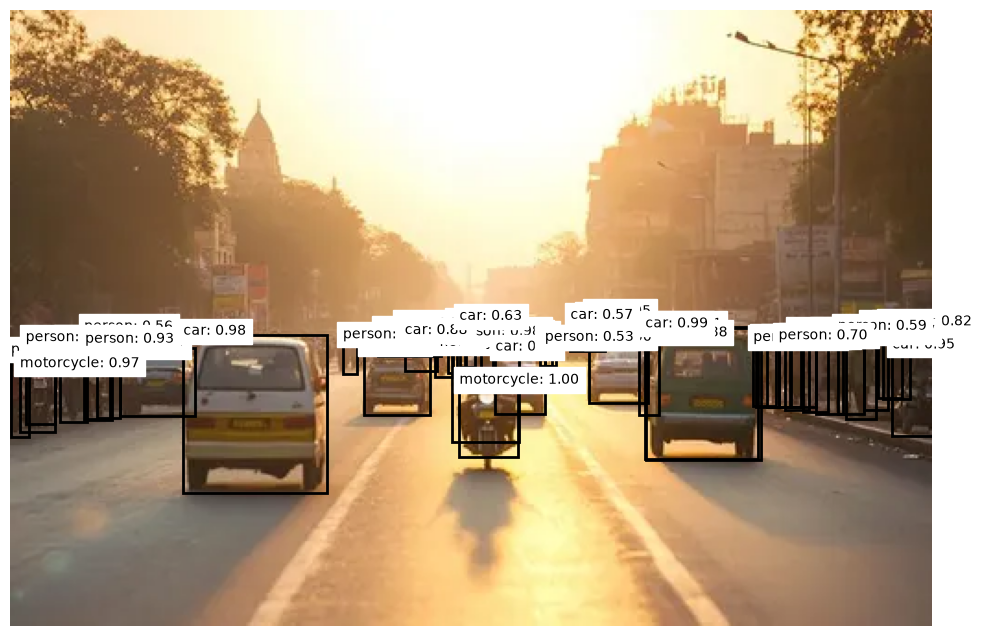

In [27]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

fig, ax = plt.subplots(figsize=(14, 8))

ax.imshow(image)

for detection in detections:
    label = detection["label"]
    score = detection["score"]
    box = detection["box"]

    xmin = box["xmin"]
    ymin = box["ymin"]
    xmax = box["xmax"]
    ymax = box["ymax"]

    rectangle = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )

    ax.add_patch(rectangle)

    ax.text(
        xmin,
        ymin,
        f"{label}: {score:.2f}",
        fontsize=10,
        backgroundcolor="white" 
    )

ax.axis("off")
plt.show()